# DEMO: Brain

In the Brain dataset, we integrate two adjacent brain slices from RIBOmap and STARmap technological platforms using ARIEL. Compared to the baseline using single information source, incorporating gene information with ARIEL improves the accuracy of protein prediction.

In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import math
import torch
import matplotlib.pyplot as plt
import scanpy as sc
import squidpy as sq
import anndata as ad
import pandas as pd
import anndata
from sklearn.linear_model import LassoCV
from ariel_srt.Landmark import normalization_spatial, Rasterization, alternative_landmark, screen_landmark
from ariel_srt.Alignment import rigid_alignment
from ariel_srt.Transfer import Appro_GP



E:\ProgramFiles\anaconda3\envs\gpu\lib\site-packages\xarray_schema\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
E:\ProgramFiles\anaconda3\envs\gpu\lib\site-packages\numba\core\decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [ ]:
path = './data/brain'
# path = 'D:/数据+代码/data/brain'
device = "cuda" if torch.cuda.is_available() else "cpu"

## ARIEL

In [3]:
RIBOmap2=sc.read_h5ad(f'{path}/RIBOmap2.h5ad')
STARmap2=sc.read_h5ad(f'{path}/STARmap2.h5ad')
embedding1=pd.read_csv(f'{path}/RIBOmap2_embedding.csv')
embedding2=pd.read_csv(f'{path}/STARmap2_embedding.csv')
embedding1=np.array(embedding1).T
embedding2=np.array(embedding2).T
RIBOmap2.obsm['embedding']=embedding1
STARmap2.obsm['embedding']=embedding2

### Select landmarks

In [4]:
spatial1 = normalization_spatial(RIBOmap2.obsm['spatial'])
RIBOmap2.obsm['spatial'] = spatial1

In [5]:
spatial_new1, embedding_new1=Rasterization(RIBOmap2.obsm['spatial'],RIBOmap2.obsm['embedding'],nx=40,ny=40)
spatial_new2, embedding_new2=Rasterization(STARmap2.obsm['spatial'],STARmap2.obsm['embedding'],nx=40,ny=40)

In [6]:
lm1, lm2 = alternative_landmark(spatial_new1, spatial_new2, embedding_new1, embedding_new2)

In [7]:
lm1, lm2 = screen_landmark(lm1, lm2)

### Alignment

In [8]:
lm2_tran, spatial2= rigid_alignment(lm1, lm2, STARmap2.obsm['spatial'])

C:\Users\10848\AppData\Local\Temp\ipykernel_21788\839439138.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(spatial1[:,0],


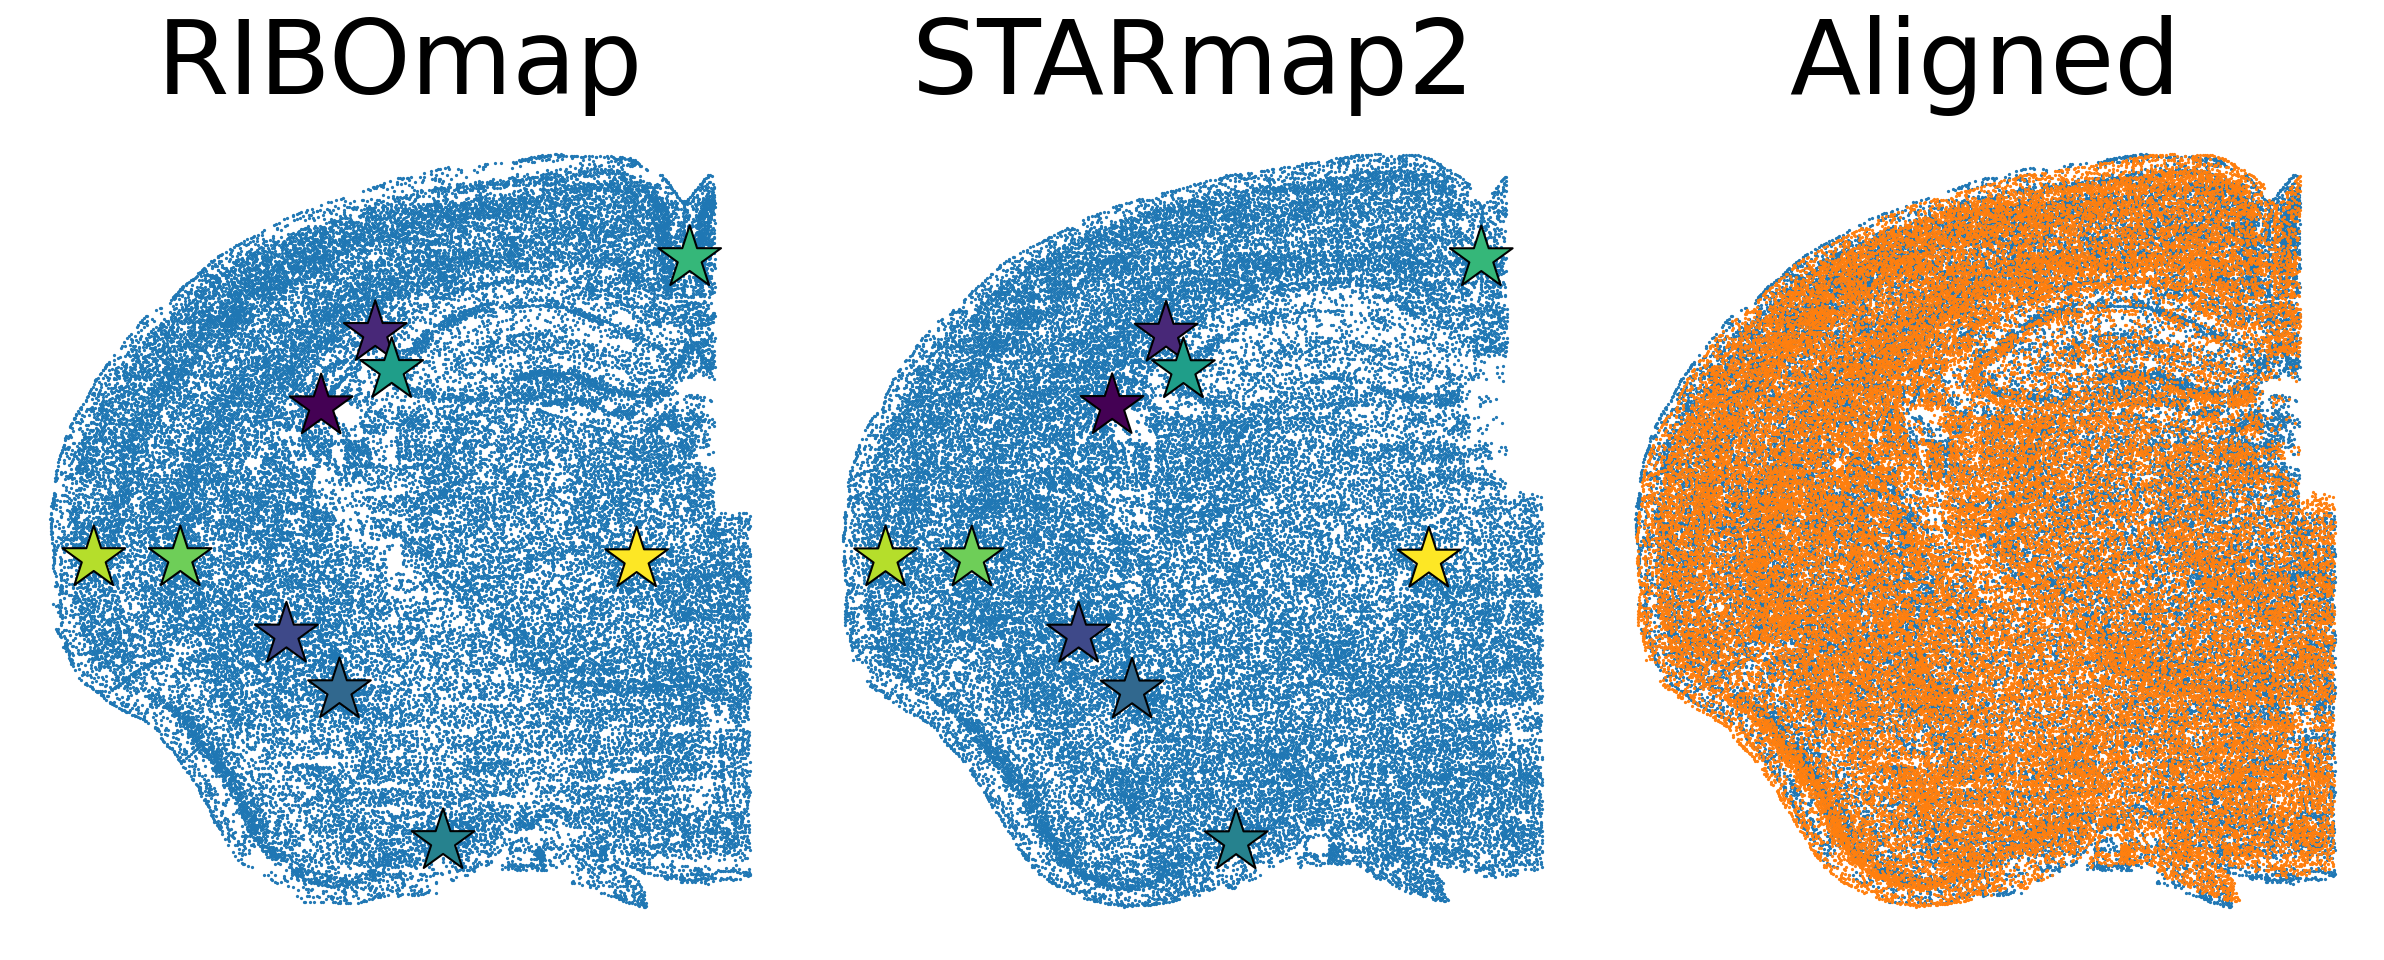

In [9]:
plt.figure(dpi=150,figsize=(16,6.5))

plt.subplot(1,3, 1)
plt.scatter(spatial1[:,0],
            spatial1[:,1],
            cmap='PuBu',
            s = 0.3)
plt.axis("off")
plt.scatter(lm1[:,0],lm1[:,1],s=1000, c = range(lm1.shape[0]), marker = "*",edgecolor = "black")
plt.title('RIBOmap',fontsize=50)
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

plt.subplot(1,3, 2)
plt.scatter(STARmap2.obsm["spatial"][:,0],
            STARmap2.obsm["spatial"][:,1],
            s = 0.3)
plt.scatter(lm2[:,0],lm2[:,1],s=1000, c = range(lm2_tran.shape[0]), marker = "*",edgecolor = "black")
plt.axis("off")
plt.title('STARmap2',fontsize=50)
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

plt.subplot(1,3, 3)
plt.scatter(spatial1[:,0],
            spatial1[:,1],
            s = 0.3)
plt.scatter(spatial2[:,0],
            spatial2[:,1],
            s = 0.3)
plt.axis("off")
plt.title('Aligned',fontsize=50)
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

plt.tight_layout()

### Information transfer

#### STARmap to RIBOmap

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [11]:
x1=np.array(spatial1)
x2=np.array(spatial2)
y2=STARmap2.obsm['X_pca']


x1=torch.tensor(x1).float()
x2=torch.tensor(x2).float()
y2=torch.tensor(y2).float()


In [14]:
prediction_pca = Appro_GP(x1, x2, y2, device)
if(device == 'cpu'):
    prediction_pca=prediction_pca.detach().numpy()
else:
    prediction_pca=prediction_pca.detach().cpu().numpy()
# Reconstruction
y_predict2_pca_all=np.dot(prediction_pca,STARmap2.varm['PCs'].T)
# Save
pd.DataFrame(y_predict2_pca_all).to_csv(f'{path}/STARmap2_predict_pca_all_machine.csv',header=False, index=False)

In [10]:
y_predict2_pca_all=np.array(pd.read_csv(f'{path}/STARmap2_predict_pca_all_machine.csv',header=None))
n_x2=y_predict2_pca_all.copy()

for i in range(y_predict2_pca_all.shape[1]):
    n_x2[:,i]=n_x2[:,i]-np.min(n_x2[:,i])


In [11]:
sq.gr.spatial_neighbors(STARmap2)
sq.gr.spatial_autocorr(STARmap2,mode="moran",)
sq.gr.spatial_neighbors(RIBOmap2)
sq.gr.spatial_autocorr(RIBOmap2,mode="moran",)

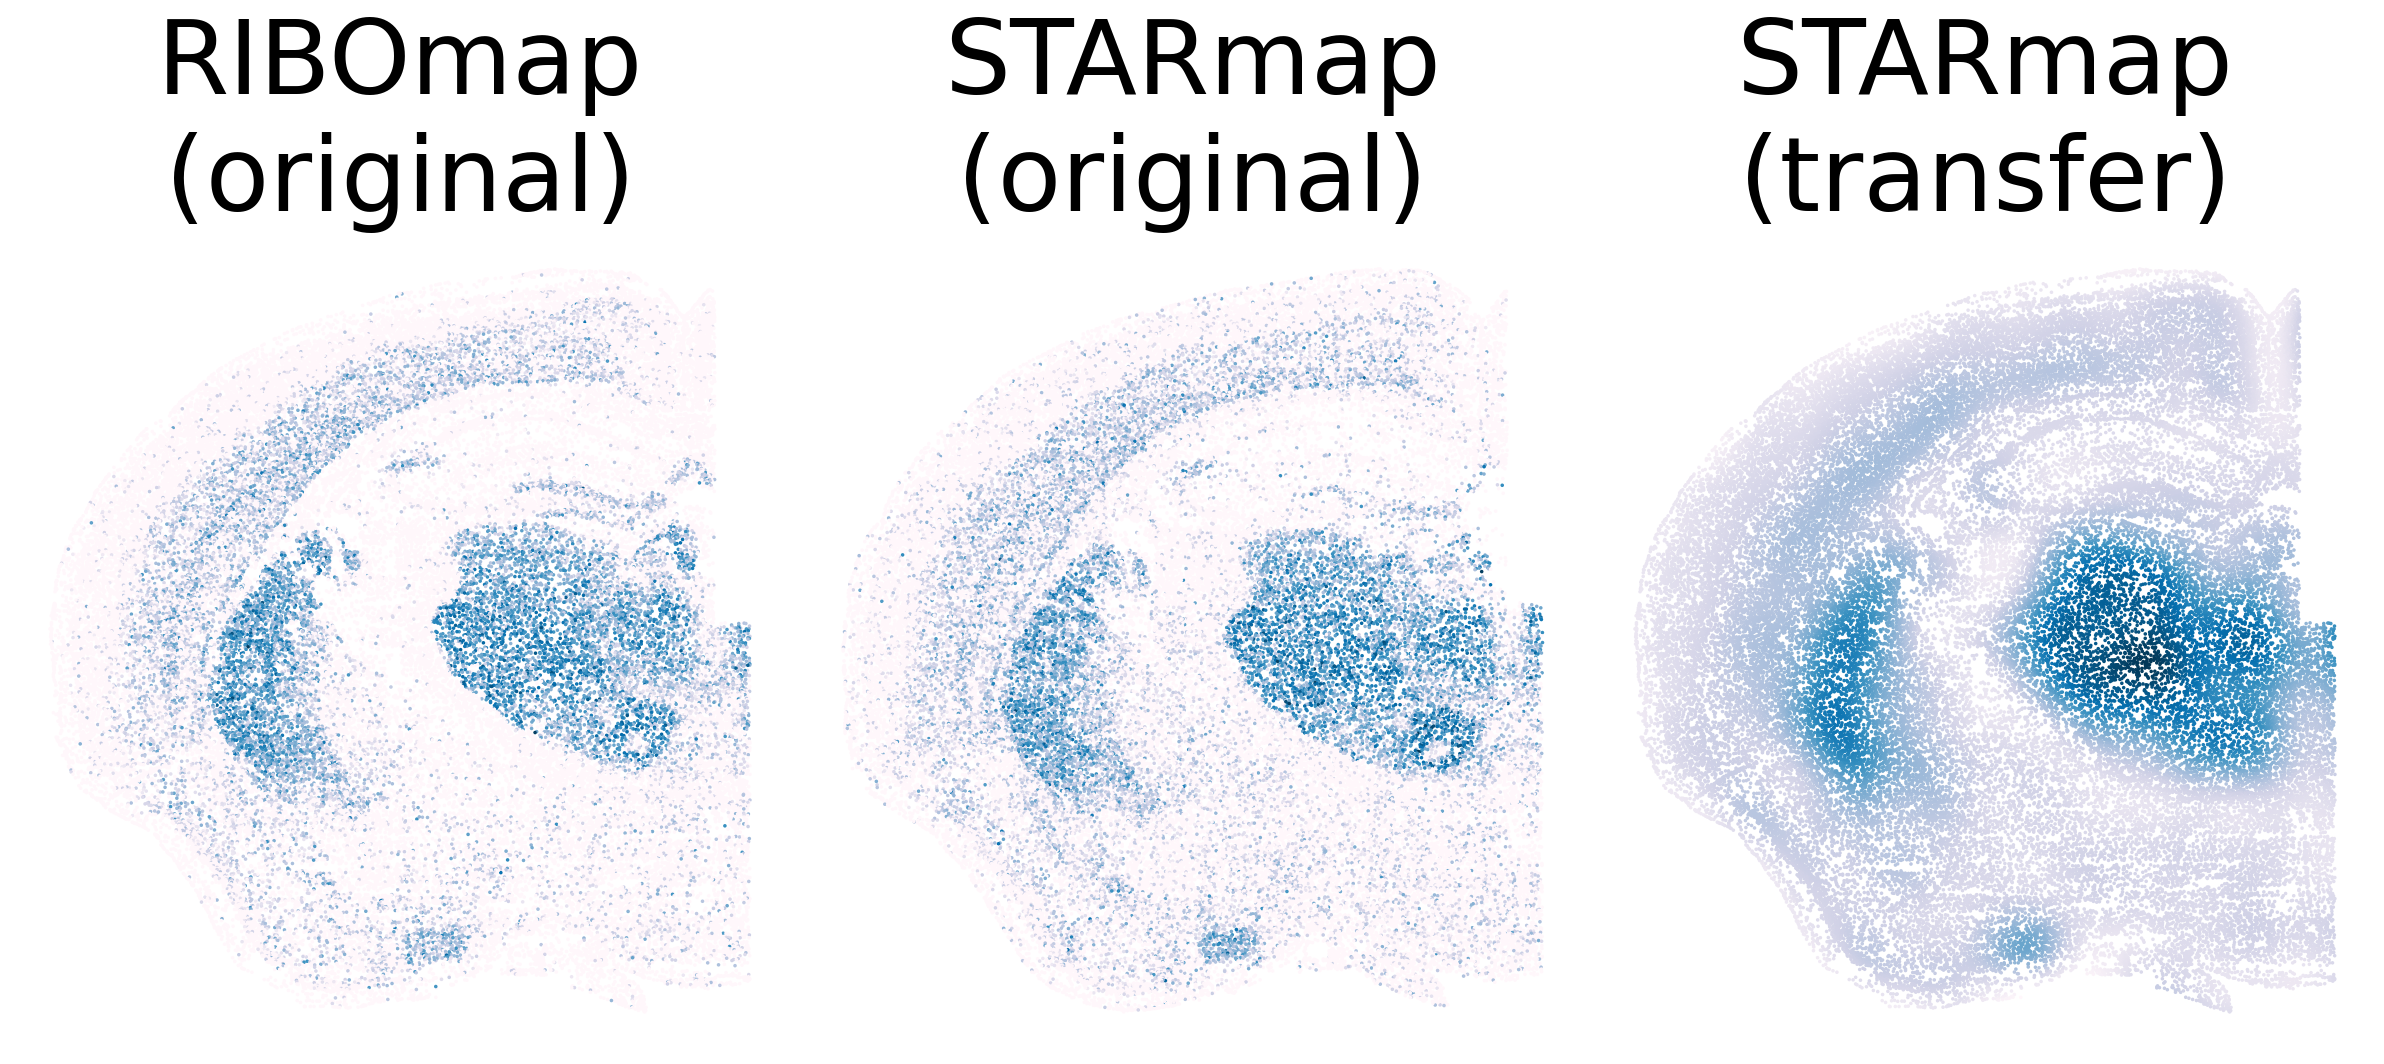

In [12]:
plt.figure(dpi=150,figsize=(16,7.2))

plt.subplot(1,3, 1)
plt.scatter(spatial1[:,0],
            spatial1[:,1],
            c = RIBOmap2.X[:,np.where(RIBOmap2.var_names == 'Pcp4')[0][0]],
            cmap='PuBu',
            s = 0.5)
plt.axis("off")
plt.title('RIBOmap\n(original)', fontsize = 50)
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

plt.subplot(1,3, 2)
plt.scatter(STARmap2.obsm["spatial"][:,0],
            STARmap2.obsm["spatial"][:,1],
            c = STARmap2.X[:,np.where(RIBOmap2.var_names == 'Pcp4')[0][0]],
            cmap='PuBu',
            s = 0.5)
plt.axis("off")
plt.title('STARmap\n(original)', fontsize = 50)
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

plt.subplot(1,3, 3)
plt.scatter(spatial1[:,0],
            spatial1[:,1],
            c = n_x2[:,np.where(RIBOmap2.var_names == 'Pcp4')[0][0]],
            cmap='PuBu',
            s = 0.5)
plt.axis("off")
plt.title('STARmap\n(transfer)', fontsize = 50)
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
plt.tight_layout()

## Downstream works(Protein Prediction)

### Strategy 1 (Random missing)

First, for each cell type in the RIBOmap slice, we randomly select 80% of the points as the training set and make predictions on the remaining 20% test set. In the baseline method, we train the GPR model by RIBOmap information. In contrast, the ARIEL approach utilize transferred STARmap information, selecting genes with high Moran's I index as independent variables to train a LASSO model with 5-fold cross-validation for imputing missing values. Prediction performance is evaluated using the correlation coefficient of marker genes in each brain region.

In [13]:
index2=[]
var=[]
for i in STARmap2.uns['moranI'].index[range(200)]:
    index2.append(np.where(STARmap2.var_names==i)[0][0])
    var.append(i)

n_x2_fit=n_x2[:,index2]

In [ ]:
import random
from sklearn.linear_model import LassoCV
random.seed(4321)
for k in range(10):
    for j in np.unique(RIBOmap2.obs['cell_type']):
        train_size=int(np.sum(RIBOmap2.obs['cell_type']==j)*0.8)
        train=random.sample(np.where(RIBOmap2.obs['cell_type']==j)[0].tolist(),train_size)
        test=list(set(np.where(RIBOmap2.obs['cell_type']==j)[0].tolist())-set(train))
        
        globals()[f'marker_{j}']=np.array(pd.read_csv(f"{path}/marker_{j}.csv", index_col=0 ))[:,0]
        
        for i in globals()[f'marker_{j}']:
            lasso=LassoCV(cv=5).fit(n_x2_fit[train,:],RIBOmap2.X[train,np.where(RIBOmap2.var_names==i)[0][0]])
            globals()[f'cor_lasso_{j}_{i}_{k}']=np.corrcoef(lasso.predict(n_x2_fit[test,:]),RIBOmap2.X[test,np.where(RIBOmap2.var_names==i)[0][0]])[1,0]

        x1=np.array(spatial1[train,:])
        x1_1=np.array(spatial1[test,:])
        index_marker=[]
        for i in globals()[f'marker_{j}']:
            index_marker.append(np.where(RIBOmap2.var_names==i)[0][0])
        y1=RIBOmap2[train,index_marker].X
        x1=torch.tensor(x1).float()
        x1_1=torch.tensor(x1_1).float()
        y1=torch.tensor(y1).float()
        if(x1_1.shape[0]<500):
            prediction = Exact_GP(x1_1, x1, y1,device)
        else:
            prediction = Appro_GP(x1_1, x1, y1,device)

        if(device == 'cpu'):
            prediction=prediction.detach().numpy()
        else:
            prediction=prediction.detach().cpu().numpy()
            
        n_x1_testing = prediction.copy()
        for i in range(prediction.shape[1]):
            n_x1_testing[:,i]=n_x1_testing[:,i]-np.min(n_x1_testing[:,i])
            var = RIBOmap2.var_names[index_marker[i]]
            globals()[f'cor_baseline_{j}_{var}_{k}']=np.corrcoef(n_x1_testing[:,i],RIBOmap2.X[test,np.where(RIBOmap2.var_names==var)[0][0]])[1,0]

In [29]:
for j in np.unique(RIBOmap2.obs['cell_type']):
    globals()[f'cor_lasso_{j}']=pd.DataFrame(columns=globals()[f'marker_{j}'],index=range(10))
    globals()[f'cor_baseline_{j}']=pd.DataFrame(columns=globals()[f'marker_{j}'],index=range(10))
    
    for k in range(10):
        for i in globals()[f'marker_{j}']:
            globals()[f'cor_lasso_{j}'].loc[k,i]=globals()[f'cor_lasso_{j}_{i}_{k}']
            globals()[f'cor_baseline_{j}'].loc[k,i]=globals()[f'cor_baseline_{j}_{i}_{k}']

    globals()[f'cor_{j}']=pd.DataFrame(columns=['Baseline','ARIEL'],index=globals()[f'marker_{j}'])
    globals()[f'cor_{j}']['Baseline']=globals()[f'cor_baseline_{j}'].mean(axis=0)
    globals()[f'cor_{j}']['ARIEL']=globals()[f'cor_lasso_{j}'].mean(axis=0)

#### Comparison

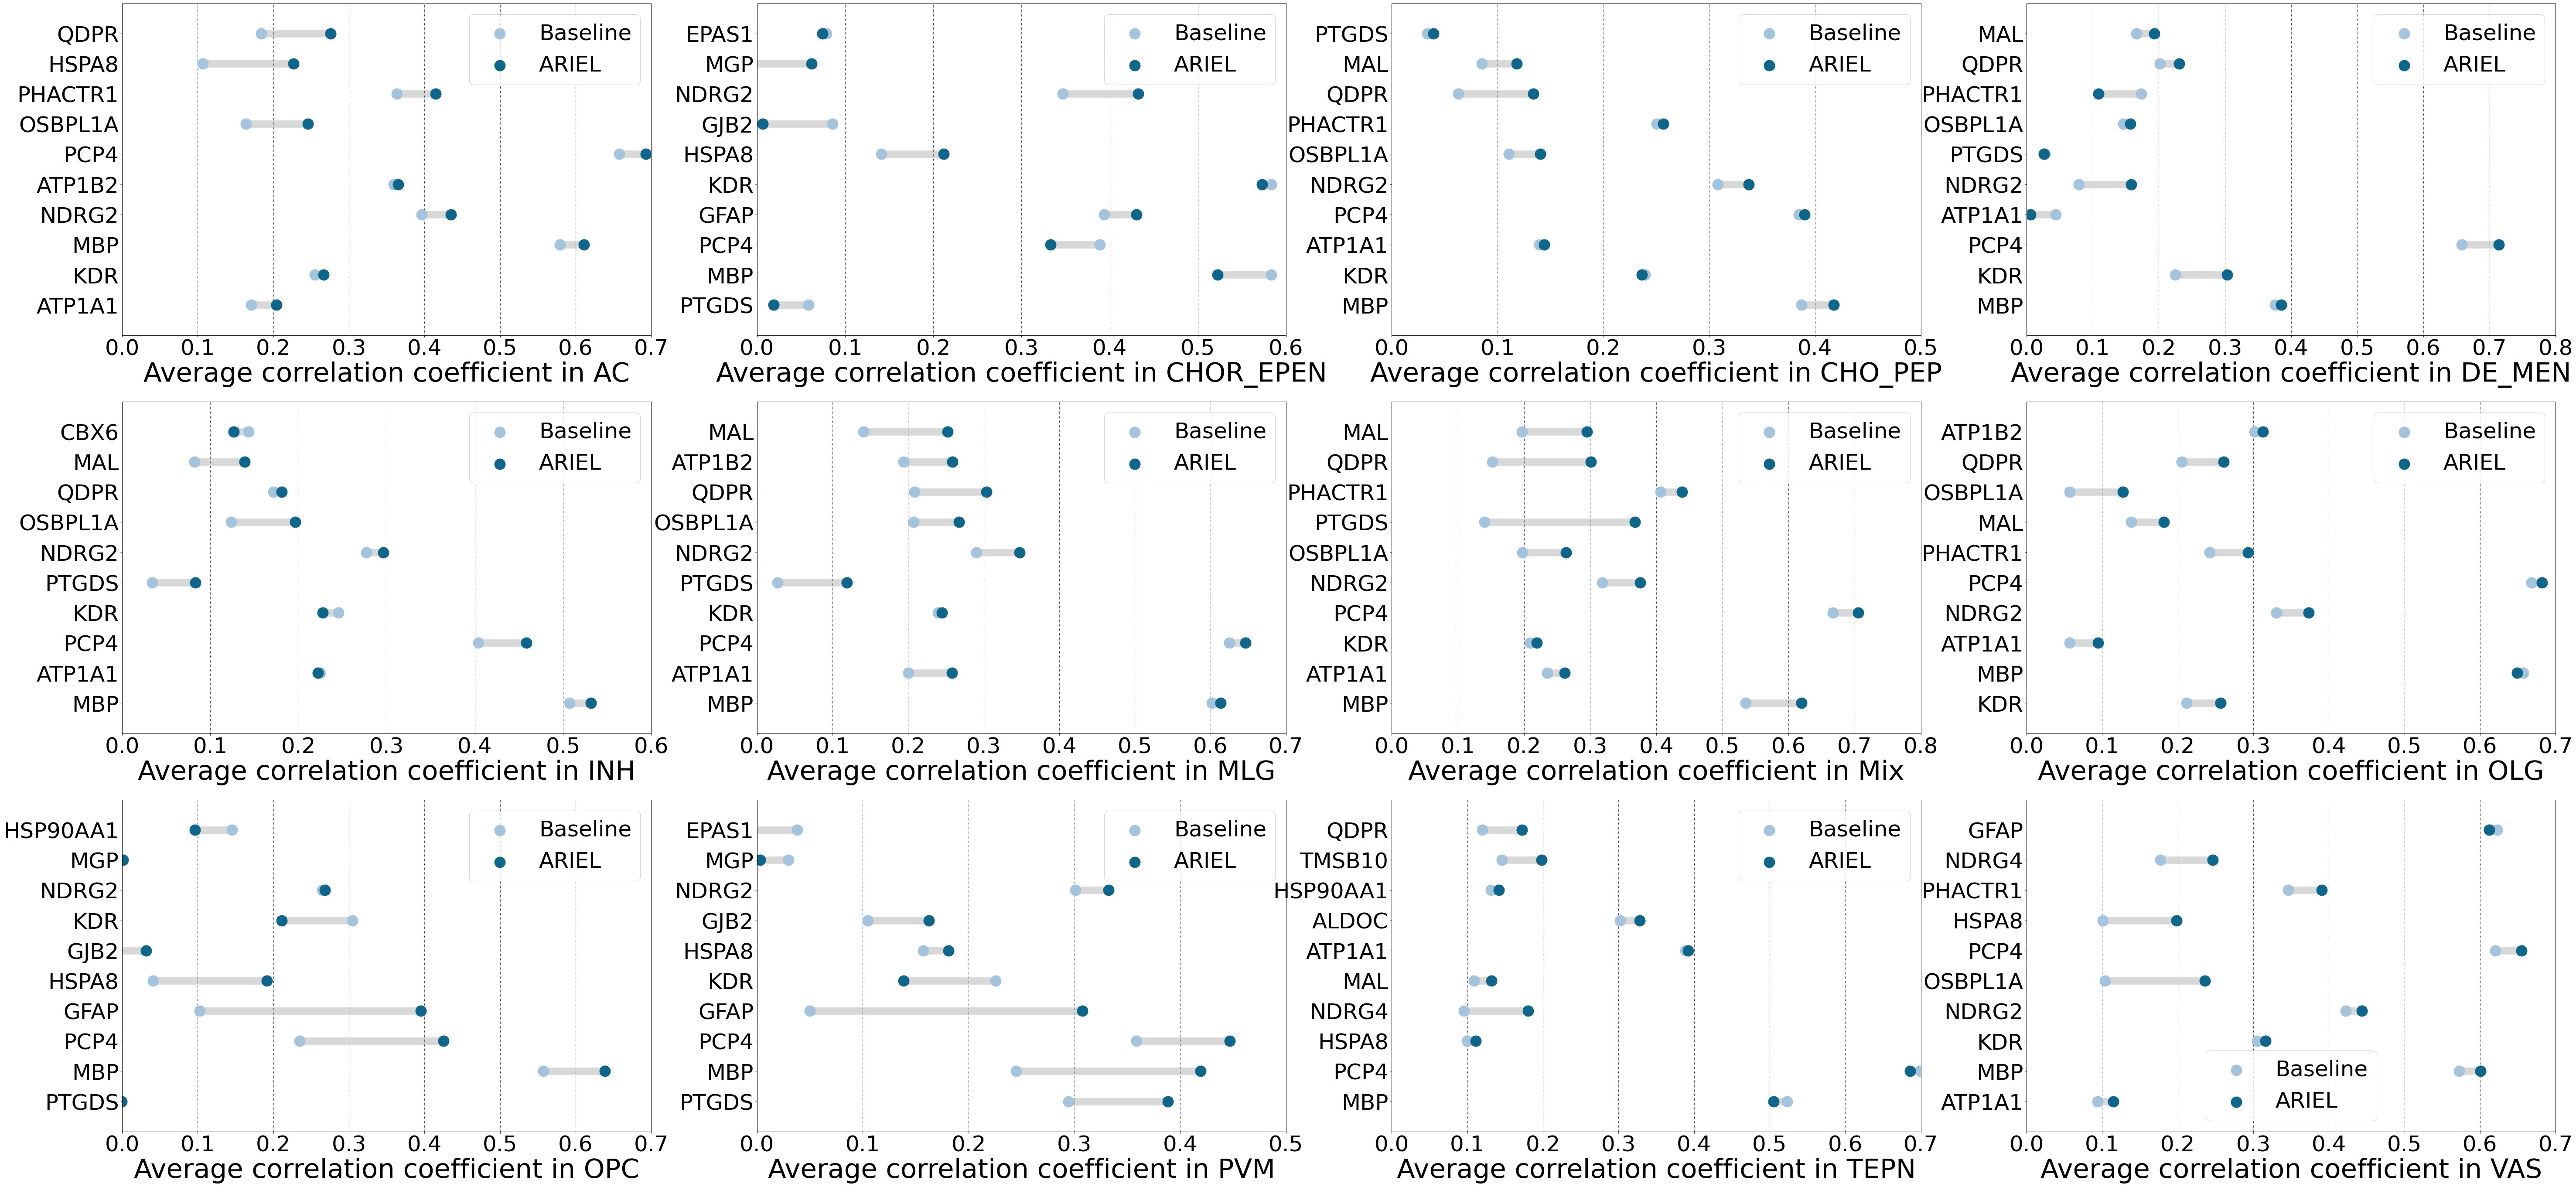

In [31]:
def newline(p1, p2, color='black'):
    ax = plt.gca()
    l = mlines.Line2D([p1[0],p2[0]], [p1[1],p2[1]], color='skyblue')
    ax.add_line(l)
    return l
    
plt.figure(figsize=(90,42), dpi= 80)

z = 1
for j in np.unique(RIBOmap2.obs['cell_type']):
    plt.subplot(3,4, z)
    z = z+1
    xindex=math.ceil(np.max(np.max(globals()[f'cor_{j}']))*10)
    
    for i in range(xindex):
        plt.vlines(x=i/10, ymin=0, ymax=11, color='black', alpha=1, linewidth=1, linestyles='dotted')

    for k in range(1,globals()[f'cor_{j}'].shape[0]+1):
        plt.hlines(y=k,xmin=np.min(globals()[f'cor_{j}'][k-1:k],axis=1),xmax=np.max(globals()[f'cor_{j}'][k-1:k],axis=1),color='grey',lw=15, alpha=0.3)
        
    plt.scatter(y=range(1,globals()[f'cor_{j}'].shape[0]+1), x=globals()[f'cor_{j}']['Baseline'], s=500, color='#a3c4dc', label='Baseline', zorder=2)
    plt.scatter(y=range(1,globals()[f'cor_{j}'].shape[0]+1), x=globals()[f'cor_{j}']['ARIEL'], s=500, color='#0e668b', label='ARIEL', zorder=2)

    plt.xlim(0,math.ceil(np.max(np.max(globals()[f'cor_{j}']))*10)/10)
    plt.ylim(0, 11)
    
    a=[]
    for i in globals()[f'cor_{j}'].index:
        a.append(i.upper())
    plt.yticks(range(1,globals()[f'cor_{j}'].shape[0]+1),a,fontsize=45)
    plt.tick_params(labelsize=45)
    plt.xlabel(f'Average correlation coefficient in {j}',fontsize=55)
    plt.legend(prop = {'size':45})
plt.show()

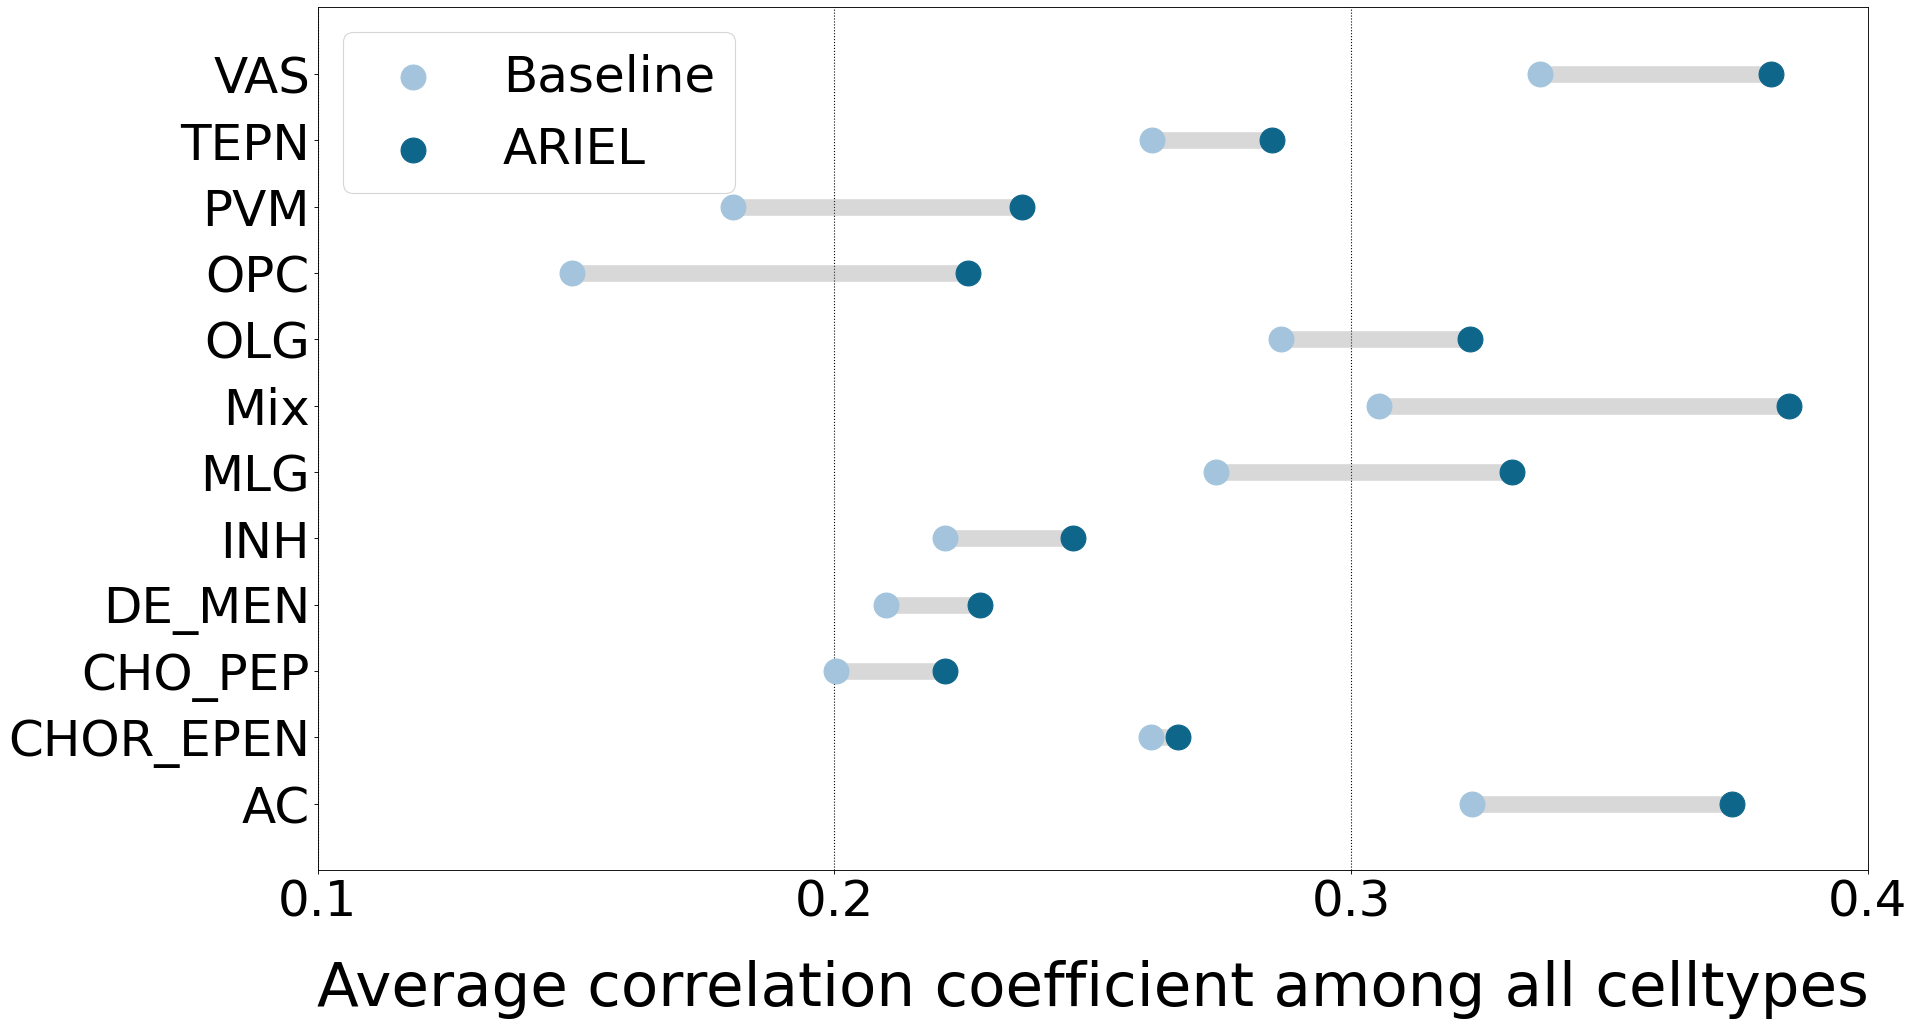

In [77]:
cor=pd.DataFrame(columns=['Baseline','ARIEL'],index=np.unique(RIBOmap2.obs['cell_type']))
for i in cor.index:
    for j in cor.columns:
        cor.loc[i,j]=np.mean(globals()[f'cor_{i}'][j])

def newline(p1, p2, color='black'):
    ax = plt.gca()
    l = mlines.Line2D([p1[0],p2[0]], [p1[1],p2[1]], color='skyblue')
    ax.add_line(l)
    return l
    
fig, ax = plt.subplots(1,1,figsize=(25,14), dpi= 80)

xindex=math.ceil(np.max(np.max(cor))*10)

x=[]
for i in range(xindex):
    ax.vlines(x=i/10, ymin=0, ymax=13, color='black', alpha=1, linewidth=1, linestyles='dotted')
    x.append(i/10)

for k in range(1,cor.shape[0]+1):
    ax.hlines(y=k,xmin=np.min(cor[k-1:k],axis=1),xmax=np.max(cor[k-1:k],axis=1),color='grey',lw=15, alpha=0.3)
        
ax.scatter(y=range(1,cor.shape[0]+1), x=cor['Baseline'], s=500, color='#a3c4dc', label='Baseline', zorder=2)
ax.scatter(y=range(1,cor.shape[0]+1), x=cor['ARIEL'], s=500, color='#0e668b', label='ARIEL', zorder=2)

ax.set(xlim=(math.ceil(np.min(np.min(cor))*10)/10,math.ceil(np.max(np.max(cor))*10)/10), ylim=(0, 13))
x = [i + 0.1 for i in x]
ax.set_xticks(x)
ax.set_yticks(range(1,cor.shape[0]+1))
ax.set_yticklabels(cor.index,fontsize=45)  
plt.tick_params(labelsize=45)
plt.xlabel(f'Average correlation coefficient among all celltypes',fontsize=55,labelpad=30)
ax.legend(prop = {'size':45})
plt.savefig(f"{path}/all.jpg",bbox_inches='tight')


### Strategy 2 (block-wise missing)

A hippocampal subregion is chosen as the testing set to show the predicion result in block-wise data absence. The prediction method by ARIEL and baseline are same as before. The Correlation coefficient between prediction and ground truth is calculated to evaluate the result.

In [65]:
marker_TEPN=np.array(pd.read_csv(f"{path}/marker_TEPN.csv", index_col=0))[:,0]

In [66]:
index2=[]
var=[]
for i in STARmap2.uns['moranI'].index[range(200)]:
    index2.append(np.where(STARmap2.var_names==i)[0][0])
    var.append(i)

n_x2_fit=n_x2[:,index2]

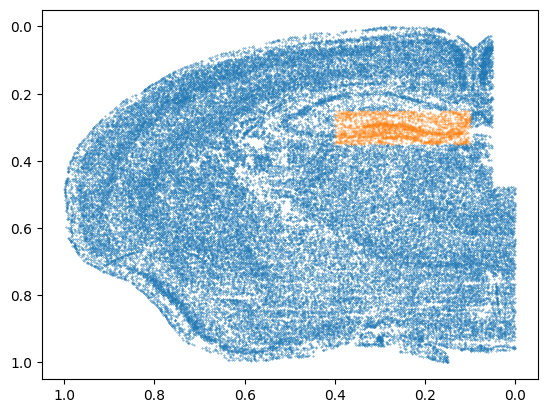

In [18]:
test=np.where((RIBOmap2.obsm['spatial'][:,0]>0.1) & (RIBOmap2.obsm['spatial'][:,0]<0.4) & (RIBOmap2.obsm['spatial'][:,1]>0.25) & (RIBOmap2.obsm['spatial'][:,1]<0.35))[0].tolist()
train=list(set(range(RIBOmap2.shape[0]))-set(test))
plt.scatter(RIBOmap2.obsm['spatial'][train,0],RIBOmap2.obsm['spatial'][train,1],s=0.1)
plt.scatter(RIBOmap2.obsm['spatial'][test,0],RIBOmap2.obsm['spatial'][test,1],s=0.1)
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

#### ARIEL (Using transferred STARmap information to predict the protein information in testing region)

In [ ]:
# prediction model based on ARIEL
for i in marker_TEPN:
    globals()[f'lasso_cv_{i}']=LassoCV(cv=5).fit(n_x2_fit[train,:],RIBOmap2.X[train,np.where(RIBOmap2.var_names==i)[0][0]])

#### Baseline (Using gaussian process regression to impute the protein information in the testing region)

In [70]:
index_marker=[]
for i in marker_TEPN:
    index_marker.append(np.where(RIBOmap2.var_names==i)[0][0])

In [71]:
x1=np.array(spatial1[train,:])
x1_1=np.array(spatial1[test,:])
y1=RIBOmap2[train,index_marker].X

x1=torch.tensor(x1).float()
x1_1=torch.tensor(x1_1).float()
y1=torch.tensor(y1).float()


In [79]:
prediction = Appro_GP(x1_1, x1, y1, device)
if(device == 'cpu'):
    prediction=prediction.detach().numpy()
else:
    prediction=prediction.detach().cpu().numpy()
pd.DataFrame(prediction).to_csv(f'{path}/RIBOmap2_predict_testing_machine.csv',header=False, index=False)

In [80]:
y_predict1_testing=pd.read_csv(f'{path}/RIBOmap2_predict_testing_machine.csv',header=None)
y_predict1_testing=np.array(y_predict1_testing)

In [81]:
n_x1_testing=y_predict1_testing.copy()
for i in range(y_predict1_testing.shape[1]):
    n_x1_testing[:,i]=n_x1_testing[:,i]-np.min(n_x1_testing[:,i])


#### Comparison

In [82]:
c1=0
c2=0
data1=[]
data2=[]
j=0
for i in index_marker:
    c=np.corrcoef(RIBOmap2.X[test,i],globals()[f'lasso_cv_{RIBOmap2.var_names[i]}'].predict(n_x2_fit[test,:]))[1,0]
    c1=c+c1
    data1.append(c)
    
    c=np.corrcoef(n_x1_testing[:,j],RIBOmap2.X[test,i])[1,0]
    c2=c+c2
    data2.append(c)
    j=j+1

In [83]:
data = pd.DataFrame(np.array(data1+data2))
data.columns = ['Correlation coefficient']
data['method'] = np.append(np.repeat('ARIEL',10),np.repeat('Baseline',10))
marker = []
for i in RIBOmap2.var_names[index_marker]:
    marker.append(i.upper())
for i in RIBOmap2.var_names[index_marker]:
    marker.append(i.upper())
data['marker'] = marker

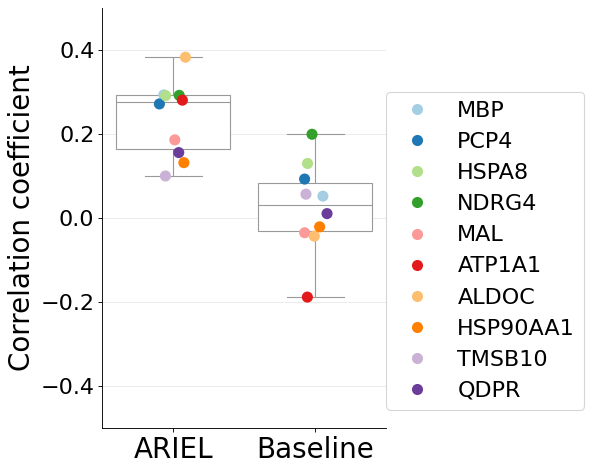

In [93]:
from matplotlib.ticker import MultipleLocator
import seaborn as sns
fig, ax =  plt.subplots(1,1,figsize=(7.5,6), dpi= 80)
sns.boxplot(data = data, x = 'method', y = 'Correlation coefficient', color='white')
plt.xticks(fontsize=25)
plt.yticks(fontsize=20)
plt.ylabel("Correlation coefficient",fontsize=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.ylim(-0.5,0.5)
y_major_locator=MultipleLocator(0.2)
ax.yaxis.set_major_locator(y_major_locator)
ax.yaxis.grid(color='lightgray',linewidth=0.5,alpha=0.8)

point_plot = sns.stripplot(data = data, x = 'method', y = 'Correlation coefficient', hue='marker' , jitter=True,palette = sns.color_palette("Paired",10),s=10)
plt.xlabel('')
plt.ylabel("Correlation coefficient", fontsize=25)
plt.legend(prop = {'size':20},bbox_to_anchor=(1, 0.8), loc=0, borderaxespad=0)
plt.tight_layout()
plt.savefig(f"{path}/box.jpg",bbox_inches='tight')